In [17]:
"""
NBA Player Archetype Clustering — By Decade
Runs independent PCA + K-means for each decade, allowing
the number of clusters to differ across eras.

Decades: 1970s, 1980s, 1990s, 2000s, 2010s
"""

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")



# CONFIG
DB_PATH      = "nba.sqlite"
MIN_GAMES    = 20
K_RANGE      = range(3, 10)   # skip k=2 (good vs. bad players)
PCA_VARIANCE = 0.95

DECADES = {
    "1970s": (1970, 1979),
    "1980s": (1980, 1989),
    "1990s": (1990, 1999),
    "2000s": (2000, 2009),
    "2010s": (2010, 2019),
}



# You can override k for a specific decade if you want to force it.
# Set to None to let silhouette decide automatically.
K_OVERRIDES = {
    "1970s": None,
    "1980s": None,
    "1990s": 5,    
    "2000s": 5,    
    "2010s": 4,
}
CLUSTER_FEATURES = [
    "pts_pg",
    "rebounds_pg",
    "assists_pg",
    "steals_pg",
    "blocks_pg",
    "turnovers_pg",
    "fg3_made_pg",
    "fg_pct",
    "ft_att_pg",
    "ast_to_tov_ratio",
    "reb_share",
]

In [4]:
print("STEP 1: Extracting play-by-play data for all decades...")
print("        (single pass — filters applied per decade later)")


conn = sqlite3.connect(DB_PATH)

raw = pd.read_sql("""
    SELECT
        pbp.player1_id                        AS player_id,
        pbp.player1_name                      AS player_name,
        gs.season,

        SUM(CASE WHEN pbp.eventmsgtype = 1 THEN 1 ELSE 0 END)   AS fg_made,
        SUM(CASE WHEN pbp.eventmsgtype = 2 THEN 1 ELSE 0 END)   AS fg_missed,
        SUM(CASE WHEN pbp.eventmsgtype = 1
             AND (pbp.homedescription    LIKE '%3PT%'
               OR pbp.visitordescription LIKE '%3PT%')
             THEN 1 ELSE 0 END)                                  AS fg3_made,
        SUM(CASE WHEN pbp.eventmsgtype = 3
             AND (pbp.homedescription    LIKE '%PTS%'
               OR pbp.visitordescription LIKE '%PTS%')
             THEN 1 ELSE 0 END)                                  AS ft_made,
        SUM(CASE WHEN pbp.eventmsgtype = 3
             AND (pbp.homedescription    LIKE '%MISS%'
               OR pbp.visitordescription LIKE '%MISS%')
             THEN 1 ELSE 0 END)                                  AS ft_missed,
        SUM(CASE WHEN pbp.eventmsgtype = 4 THEN 1 ELSE 0 END)   AS rebounds,
        SUM(CASE WHEN pbp.eventmsgtype = 5 THEN 1 ELSE 0 END)   AS turnovers,
        SUM(CASE WHEN pbp.eventmsgtype = 6 THEN 1 ELSE 0 END)   AS fouls,
        COUNT(DISTINCT pbp.game_id)                              AS games_played

    FROM play_by_play pbp
    JOIN game_summary gs ON pbp.game_id = gs.game_id
    WHERE pbp.player1_id   IS NOT NULL
      AND pbp.player1_id   != 0
      AND pbp.player1_name IS NOT NULL
    GROUP BY pbp.player1_id, pbp.player1_name, gs.season
""", conn)

ast_stl = pd.read_sql("""
    SELECT
        pbp.player2_id    AS player_id,
        gs.season,
        SUM(CASE WHEN pbp.eventmsgtype = 1 THEN 1 ELSE 0 END)   AS assists,
        SUM(CASE WHEN pbp.eventmsgtype = 5
             AND (pbp.homedescription    LIKE '%STEAL%'
               OR pbp.visitordescription LIKE '%STEAL%')
             THEN 1 ELSE 0 END)                                  AS steals
    FROM play_by_play pbp
    JOIN game_summary gs ON pbp.game_id = gs.game_id
    WHERE pbp.player2_id IS NOT NULL
      AND pbp.player2_id != 0
    GROUP BY pbp.player2_id, gs.season
""", conn)

blk = pd.read_sql("""
    SELECT
        pbp.player3_id    AS player_id,
        gs.season,
        SUM(CASE WHEN pbp.eventmsgtype = 2
             AND (pbp.homedescription    LIKE '%BLOCK%'
               OR pbp.visitordescription LIKE '%BLOCK%')
             THEN 1 ELSE 0 END)                                  AS blocks
    FROM play_by_play pbp
    JOIN game_summary gs ON pbp.game_id = gs.game_id
    WHERE pbp.player3_id IS NOT NULL
      AND pbp.player3_id != 0
    GROUP BY pbp.player3_id, gs.season
""", conn)

conn.close()
print(f"  Raw player1 rows: {len(raw):,}")
print(f"  Assists/steals rows: {len(ast_stl):,}")
print(f"  Blocks rows: {len(blk):,}")

STEP 1: Extracting play-by-play data for all decades...
        (single pass — filters applied per decade later)
  Raw player1 rows: 16,457
  Assists/steals rows: 13,446
  Blocks rows: 12,506


In [5]:
# STEP 2 — MERGE + ENGINEER FEATURES (full dataset)
print("\nSTEP 2: Merging and engineering features...")
raw_agg = (raw.groupby(["player_id", "player_name", "season"])
              .agg(
                  fg_made      = ("fg_made",      "sum"),
                  fg_missed    = ("fg_missed",    "sum"),
                  fg3_made     = ("fg3_made",     "sum"),
                  ft_made      = ("ft_made",      "sum"),
                  ft_missed    = ("ft_missed",    "sum"),
                  rebounds     = ("rebounds",     "sum"),
                  turnovers    = ("turnovers",    "sum"),
                  fouls        = ("fouls",        "sum"),
                  games_played = ("games_played", "sum"),
              ).reset_index())
ast_stl_agg = (ast_stl.groupby(["player_id", "season"])[["assists","steals"]]
                       .sum().reset_index())
blk_agg = (blk.groupby(["player_id", "season"])[["blocks"]]
              .sum().reset_index())
df = (raw_agg
      .merge(ast_stl_agg, on=["player_id", "season"], how="left")
      .merge(blk_agg,     on=["player_id", "season"], how="left")
      .fillna(0))
df["season"] = df["season"].astype(int)

# feature engineering
df["fg_att"] = df["fg_made"] + df["fg_missed"]
df["ft_att"] = df["ft_made"] + df["ft_missed"]
df["pts"]    = (df["fg_made"] - df["fg3_made"]) * 2 \
             + df["fg3_made"] * 3 \
             + df["ft_made"]
df["fg_pct"] = np.where(df["fg_att"] > 0, df["fg_made"] / df["fg_att"], np.nan)
df["ft_pct"] = np.where(df["ft_att"] > 0, df["ft_made"] / df["ft_att"], np.nan)
for col in ["pts", "fg_made", "fg_att", "fg3_made", "ft_att",
            "rebounds", "assists", "steals", "blocks", "turnovers", "fouls"]:
    df[f"{col}_pg"] = df[col] / df["games_played"]
df["ast_to_tov_ratio"] = np.where(df["turnovers"] > 0,
                                   df["assists"] / df["turnovers"], np.nan)
df["reb_share"]        = np.where((df["rebounds"] + df["assists"]) > 0,
                                   df["rebounds"] / (df["rebounds"] + df["assists"]), np.nan)

# ── Pull and clean position data ──────────────────────────────────────────────
print("\n  Pulling position data from common_player_info...")
conn = sqlite3.connect(DB_PATH)
positions = pd.read_sql("""
    SELECT CAST(person_id AS INTEGER) AS player_id, position
    FROM common_player_info
""", conn)
conn.close()

positions["position"] = positions["position"].str.strip()
positions["primary_position"] = positions["position"].apply(
    lambda x: x.split("-")[0].strip() if isinstance(x, str) and x != "" else "Unknown"
)
positions = positions[["player_id", "primary_position"]].drop_duplicates("player_id")

df["player_id"] = df["player_id"].astype(int)
df = df.merge(positions, on="player_id", how="left")
df["primary_position"] = df["primary_position"].fillna("Unknown")

# ── Single MIN_GAMES filter at the end ───────────────────────────────────────
df = df[df["games_played"] >= MIN_GAMES].copy()
print(f"  Total player-seasons (all time, {MIN_GAMES}+ games): {len(df):,}")
print(f"  Position coverage: {(df['primary_position'] != 'Unknown').sum():,} / {len(df):,} player-seasons")
print(df["primary_position"].value_counts())


STEP 2: Merging and engineering features...

  Pulling position data from common_player_info...
  Total player-seasons (all time, 20+ games): 9,923
  Position coverage: 7,305 / 9,923 player-seasons
primary_position
Guard      3228
Forward    2867
Unknown    2618
Center     1210
Name: count, dtype: int64



═════════════════════════════════════════════════════════════════
  DECADE: 1970s  (1970–1979)
═════════════════════════════════════════════════════════════════
  Player-seasons available: 0
  ⚠ Insufficient data for 1970s — skipping.
    (Play-by-play likely not available for this era)

═════════════════════════════════════════════════════════════════
  DECADE: 1980s  (1980–1989)
═════════════════════════════════════════════════════════════════
  Player-seasons available: 0
  ⚠ Insufficient data for 1980s — skipping.
    (Play-by-play likely not available for this era)

═════════════════════════════════════════════════════════════════
  DECADE: 1990s  (1990–1999)
═════════════════════════════════════════════════════════════════
  Player-seasons available: 1,379
  PCA: 7 components explain 95% variance
  Silhouette best k=3 | Using k=5 (override)


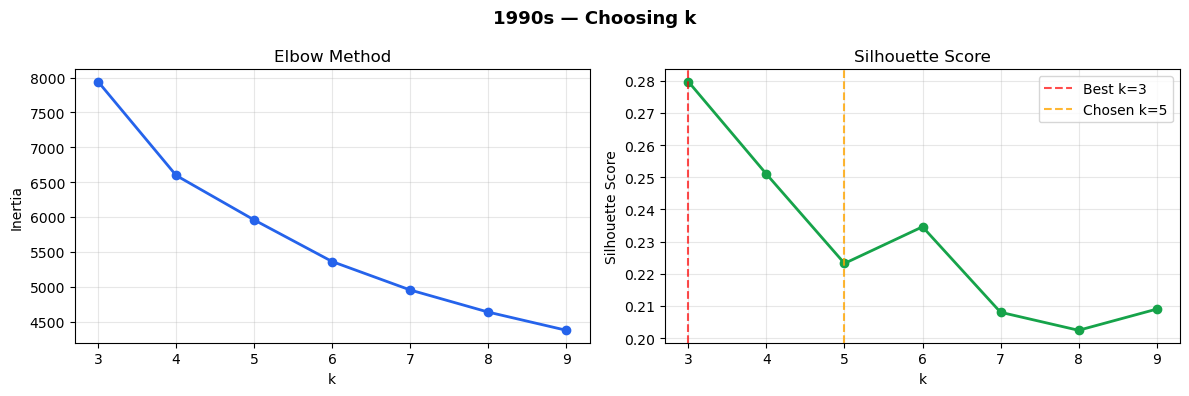

  Cluster sizes:
    Cluster 0: 376 player-seasons
    Cluster 1: 120 player-seasons
    Cluster 2: 291 player-seasons
    Cluster 3: 236 player-seasons
    Cluster 4: 356 player-seasons

  Cluster profiles:
cluster               0       1      2       3      4
pts_pg            6.815  18.612  9.389  15.293  4.090
rebounds_pg       2.097   8.967  6.242   3.951  2.664
assists_pg        2.206   2.742  1.239   4.900  0.561
steals_pg         0.714   1.049  0.760   1.452  0.372
blocks_pg         0.155   1.454  0.810   0.305  0.348
turnovers_pg      1.134   2.671  1.449   2.326  0.711
fg3_made_pg       0.719   0.263  0.092   1.199  0.126
fg_pct            0.408   0.481  0.485   0.434  0.437
ft_att_pg         1.430   5.977  2.812   3.832  1.178
ast_to_tov_ratio  2.020   1.031  0.857   2.101  0.840
reb_share         0.484   0.768  0.832   0.466  0.820


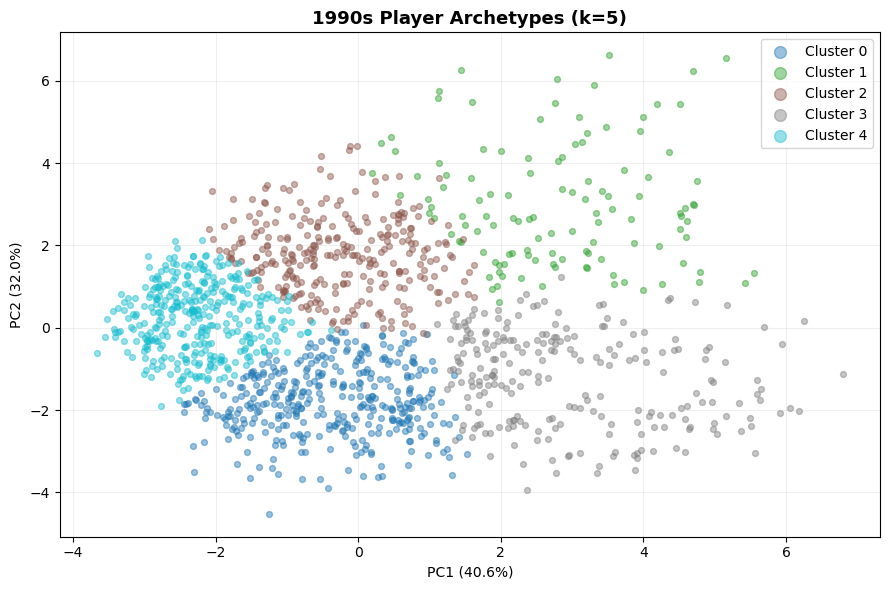

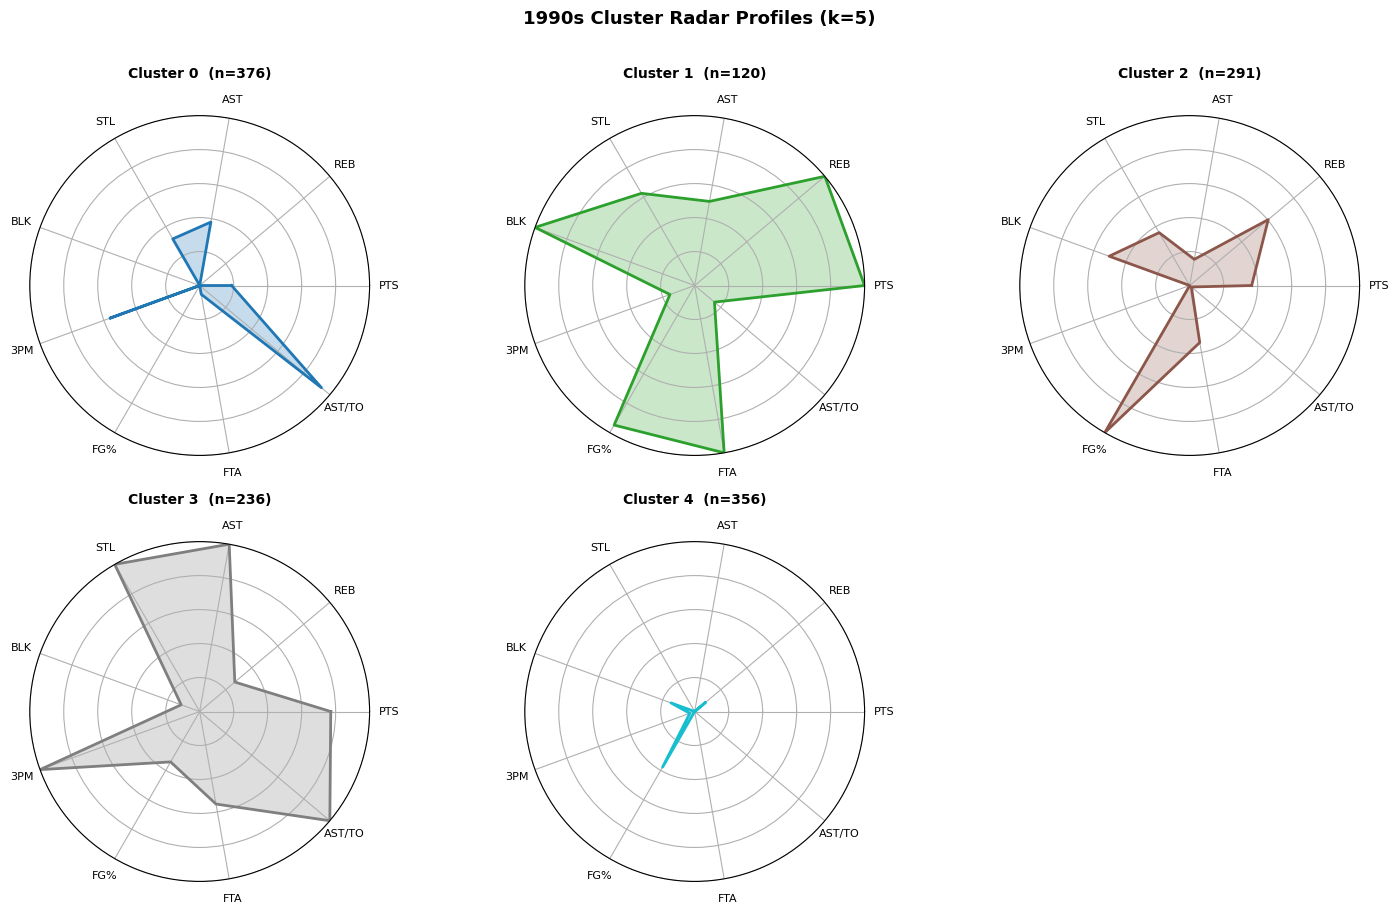


  Sample players per cluster:

  ── 1990s Cluster 0 ──
  player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
Allan Houston    1996   14.86         2.86        2.26       0.22         1.77    0.43
   Dell Curry    1996   14.73         3.00        1.64       0.22         1.85    0.47
 Tracy Murray    1997   14.44         3.28        0.93       0.21         1.97    0.44
 Isaiah Rider    1998   14.16         3.91        2.16       0.16         0.98    0.40
Wesley Person    1996   13.80         4.06        1.53       0.27         2.29    0.45

  ── 1990s Cluster 1 ──
     player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
Shaquille O'Neal    1999   29.73        13.97        3.85       3.13         0.00    0.57
  Michael Jordan    1997   29.64         5.52        3.47       0.61         0.49    0.47
     Karl Malone    1996   26.74        10.47        4.31       0.62         0.01    0.52
    Vince Carter    1999   26.19     

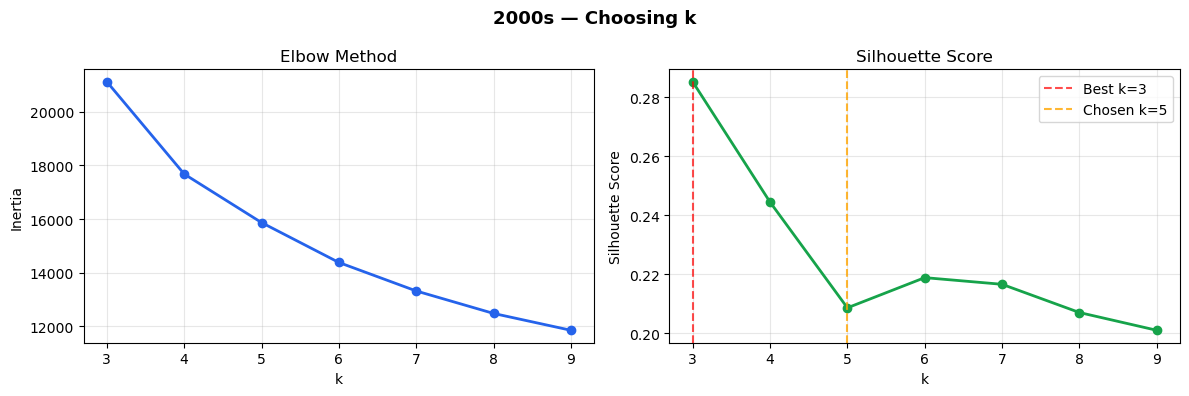

  Cluster sizes:
    Cluster 0: 908 player-seasons
    Cluster 1: 879 player-seasons
    Cluster 2: 499 player-seasons
    Cluster 3: 495 player-seasons
    Cluster 4: 880 player-seasons

  Cluster profiles:
cluster               0      1       2       3      4
pts_pg            8.453  6.308  18.500  15.203  4.434
rebounds_pg       2.625  4.506   4.508   8.452  2.247
assists_pg        2.759  0.746   5.144   2.016  0.786
steals_pg         0.801  0.486   1.367   0.903  0.403
blocks_pg         0.185  0.652   0.332   1.274  0.221
turnovers_pg      1.293  0.973   2.572   2.012  0.688
fg3_made_pg       0.844  0.083   1.355   0.286  0.382
fg_pct            0.420  0.494   0.441   0.490  0.395
ft_att_pg         1.733  1.817   4.884   4.518  1.000
ast_to_tov_ratio  2.220  0.771   2.014   1.017  1.192
reb_share         0.483  0.860   0.477   0.808  0.732


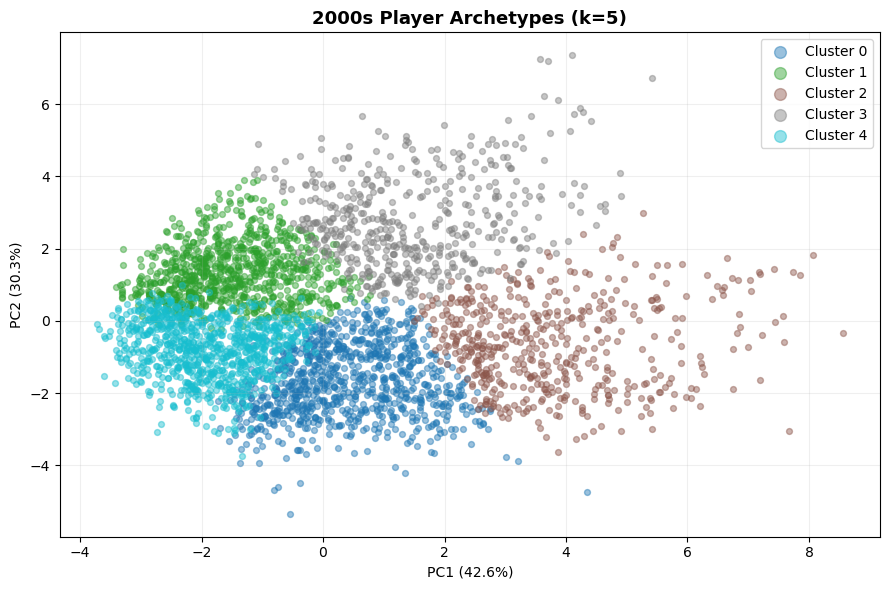

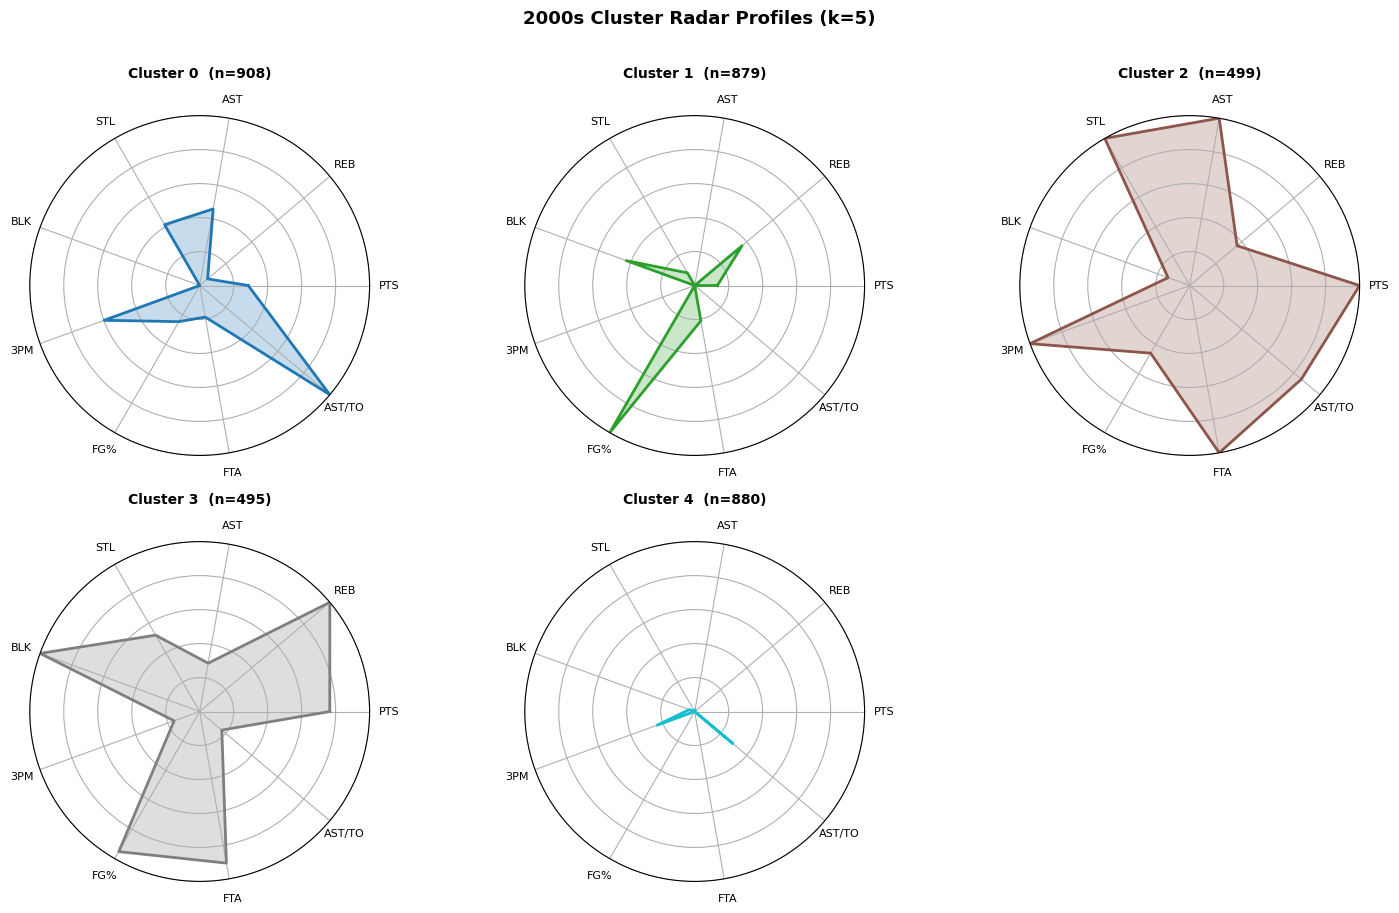


  Sample players per cluster:

  ── 2000s Cluster 0 ──
     player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
   Allan Houston    2003   17.06         2.44        2.11       0.06         1.64    0.41
Jason Richardson    2008   16.80         4.57        1.98       0.45         1.86    0.48
    Vince Carter    2009   16.63         3.97        3.14       0.15         1.55    0.44
 Peja Stojakovic    2007   16.13         4.39        1.17       0.14         2.90    0.44
     Jason Terry    2007   15.77         2.45        3.38       0.24         1.79    0.46

  ── 2000s Cluster 1 ──
       player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
    Thaddeus Young    2008   15.58         5.17        1.12       0.29         0.81    0.50
        Lee Nailon    2004   15.00         4.33        1.65       0.29         0.00    0.49
    Antawn Jamison    2003   14.33         6.38        0.86       0.42         0.22    0.53
Corliss Wil

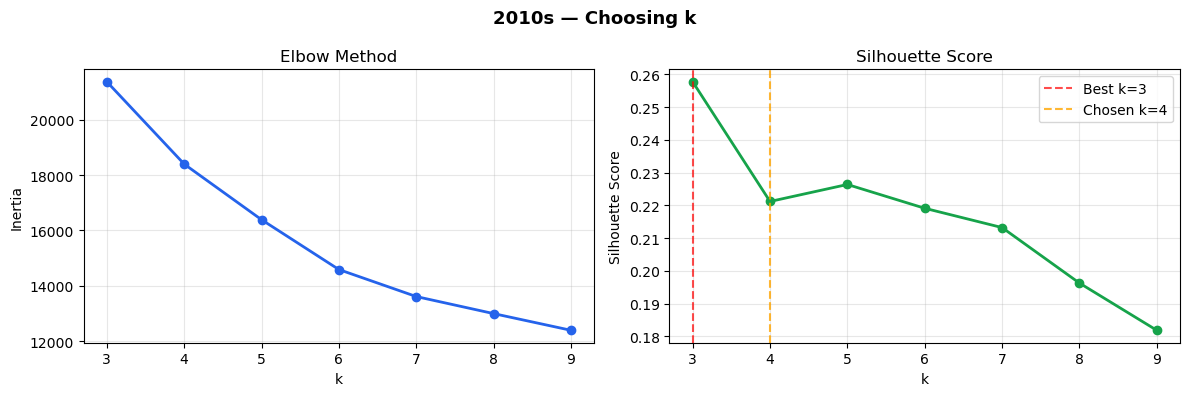

  Cluster sizes:
    Cluster 0: 656 player-seasons
    Cluster 1: 466 player-seasons
    Cluster 2: 1,186 player-seasons
    Cluster 3: 1,285 player-seasons

  Cluster profiles:
cluster                0       1      2      3
pts_pg            12.464  18.484  8.806  5.349
rebounds_pg        7.500   4.807  2.756  3.117
assists_pg         1.656   5.525  2.370  0.761
steals_pg          0.764   1.301  0.754  0.435
blocks_pg          1.053   0.409  0.227  0.367
turnovers_pg       1.550   2.664  1.193  0.723
fg3_made_pg        0.400   1.607  1.120  0.468
fg_pct             0.518   0.447  0.418  0.450
ft_att_pg          3.199   4.624  1.601  1.152
ast_to_tov_ratio   1.083   2.097  2.069  1.110
reb_share          0.820   0.465  0.533  0.793


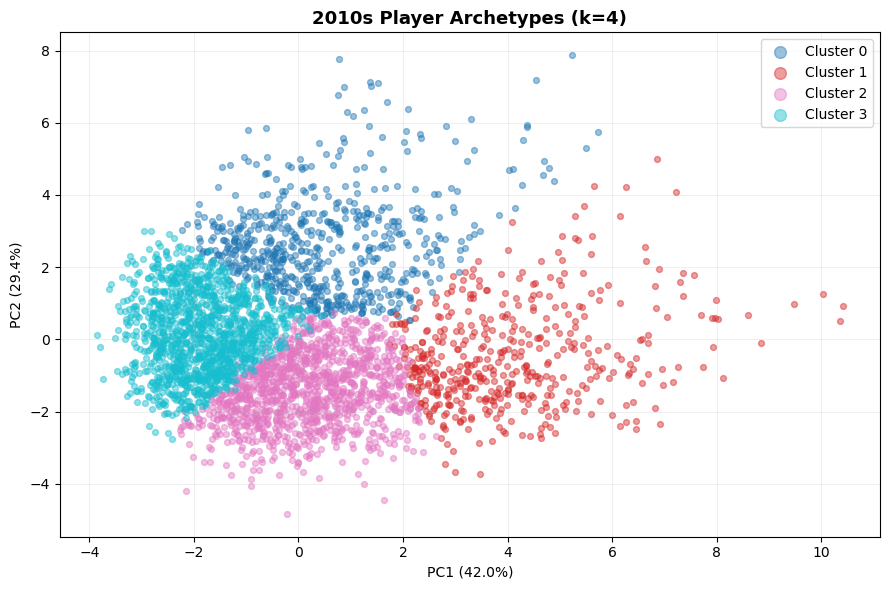

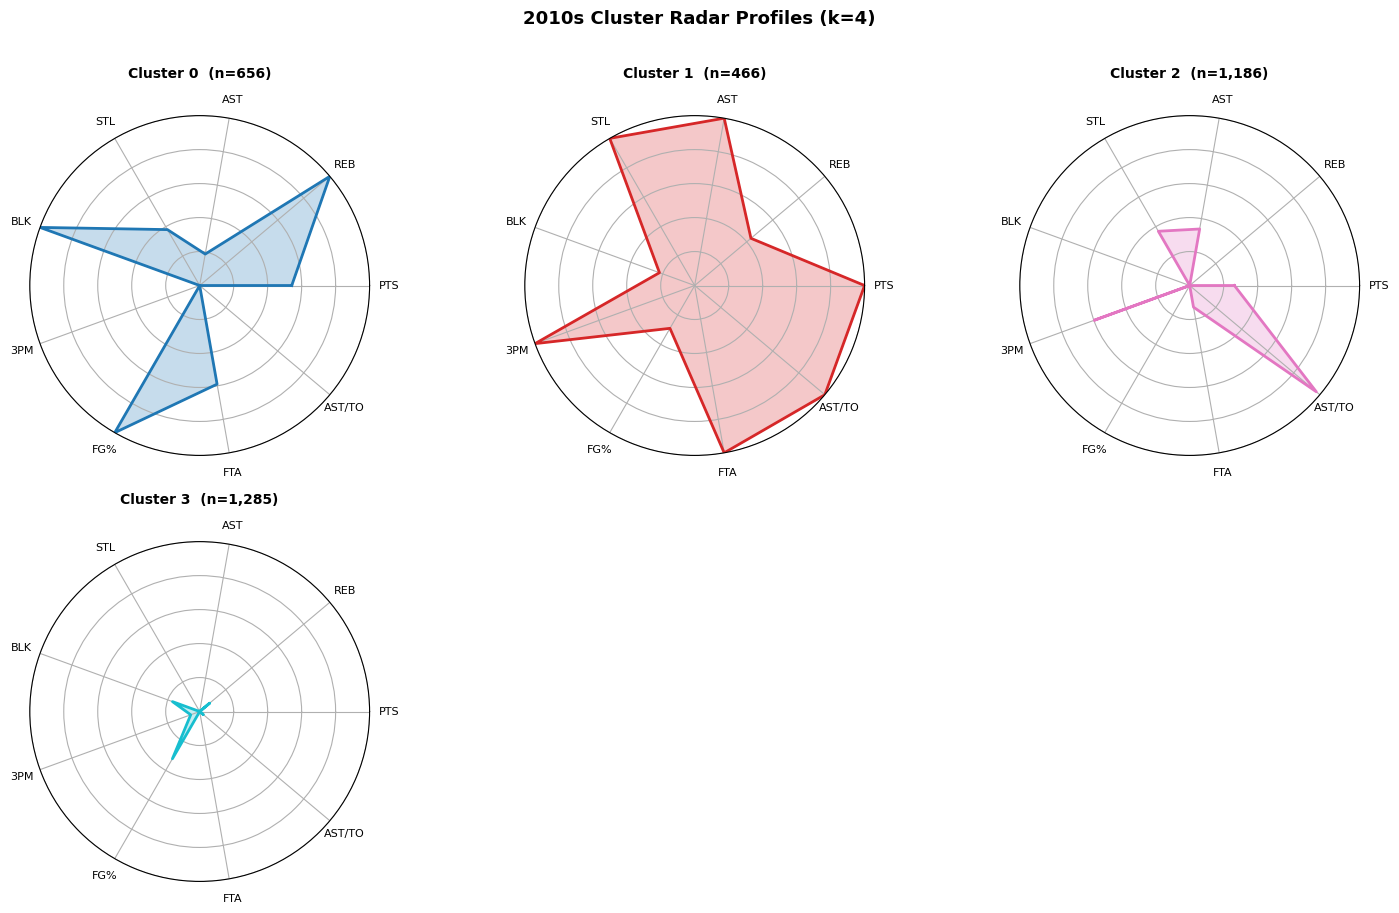


  Sample players per cluster:

  ── 2010s Cluster 0 ──
       player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
     Anthony Davis    2016   29.90        11.94        2.00       2.23         0.49    0.51
       Joel Embiid    2018   27.45        13.77        3.52       2.08         1.27    0.47
 Amar'e Stoudemire    2010   26.33         8.55        2.77       1.89         0.21    0.51
        Kevin Love    2011   25.90        13.43        1.90       0.45         2.02    0.46
Karl-Anthony Towns    2018   24.73        12.36        3.49       1.70         1.94    0.52

  ── 2010s Cluster 1 ──
          player_name  season  pts_pg  rebounds_pg  assists_pg  blocks_pg  fg3_made_pg  fg_pct
         James Harden    2018   35.78         6.89        7.59       0.73         4.88    0.43
    Russell Westbrook    2016   32.37        10.42       10.47       0.36         2.67    0.43
         Kevin Durant    2013   31.03         7.56        5.22       0.82         

In [10]:
# STEP 3 — RUN CLUSTERING PER DECADE
# Storage for cross-decade comparison
decade_results   = {}   # decade_name -> df_model with cluster labels
decade_profiles  = {}   # decade_name -> mean stats per cluster
decade_chosen_k  = {}   # decade_name -> chosen k
decade_labels    = {}   # decade_name -> {cluster_id: archetype_label}

for decade_name, (yr_start, yr_end) in DECADES.items():

    print("\n" + "═" * 65)
    print(f"  DECADE: {decade_name}  ({yr_start}–{yr_end})")
    print("═" * 65)

    # ── Filter to decade ──────────────────────────────────────────────────────
    mask      = df["season"].between(yr_start, yr_end)
    df_decade = df[mask].dropna(subset=CLUSTER_FEATURES).copy()

    print(f"  Player-seasons available: {len(df_decade):,}")

    # ── Skip if not enough data ───────────────────────────────────────────────
    if len(df_decade) < 50:
        print(f"  ⚠ Insufficient data for {decade_name} — skipping.")
        print(f"    (Play-by-play likely not available for this era)")
        continue

    # ── Scale ─────────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(df_decade[CLUSTER_FEATURES])

    # ── PCA ───────────────────────────────────────────────────────────────────
    pca_full = PCA().fit(X_scaled)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
    n_comps  = int(np.argmax(cumvar >= PCA_VARIANCE) + 1)
    print(f"  PCA: {n_comps} components explain {PCA_VARIANCE*100:.0f}% variance")

    pca      = PCA(n_components=n_comps)
    X_pca    = pca.fit_transform(X_scaled)

    pca_2d   = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)

    # ── Elbow + Silhouette ────────────────────────────────────────────────────
    inertias    = []
    silhouettes = []
    k_vals      = [k for k in K_RANGE if k < len(df_decade)]

    for k in k_vals:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_pca)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_pca, labels))

    best_k_sil = k_vals[np.argmax(silhouettes)]
    override   = K_OVERRIDES.get(decade_name)
    chosen_k   = override if override is not None else best_k_sil

    print(f"  Silhouette best k={best_k_sil} | "
          f"Using k={chosen_k}"
          f"{' (override)' if override else ''}")

    decade_chosen_k[decade_name] = chosen_k

    # ── Elbow + Silhouette plot ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{decade_name} — Choosing k", fontsize=13, fontweight="bold")

    axes[0].plot(k_vals, inertias, "o-", color="#2563EB", linewidth=2)
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")
    axes[0].set_xticks(k_vals)
    axes[0].grid(alpha=0.3)

    axes[1].plot(k_vals, silhouettes, "o-", color="#16A34A", linewidth=2)
    axes[1].axvline(best_k_sil, color="red", linestyle="--",
                    alpha=0.7, label=f"Best k={best_k_sil}")
    if override and override != best_k_sil:
        axes[1].axvline(chosen_k, color="orange", linestyle="--",
                        alpha=0.8, label=f"Chosen k={chosen_k}")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_xticks(k_vals)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"k_selection_{decade_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Fit final model ───────────────────────────────────────────────────────
    km_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
    df_decade["cluster"] = km_final.fit_predict(X_pca)

    print(f"  Cluster sizes:")
    for c, n in df_decade["cluster"].value_counts().sort_index().items():
        print(f"    Cluster {c}: {n:,} player-seasons")

    # ── Cluster profiles ──────────────────────────────────────────────────────
    profile = df_decade.groupby("cluster")[CLUSTER_FEATURES].mean().round(3)
    print(f"\n  Cluster profiles:")
    print(profile.T.to_string())

    decade_results[decade_name]  = df_decade
    decade_profiles[decade_name] = profile

    # ── PCA scatter ───────────────────────────────────────────────────────────
    colors = cm.tab10(np.linspace(0, 1, chosen_k))
    fig, ax = plt.subplots(figsize=(9, 6))
    for c in range(chosen_k):
        mask = df_decade["cluster"] == c
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   color=colors[c], alpha=0.45, s=18, label=f"Cluster {c}")
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{decade_name} Player Archetypes (k={chosen_k})",
                 fontsize=13, fontweight="bold")
    ax.legend(markerscale=2)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"scatter_{decade_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Radar charts ──────────────────────────────────────────────────────────
    radar_features = ["pts_pg", "rebounds_pg", "assists_pg", "steals_pg",
                      "blocks_pg", "fg3_made_pg", "fg_pct",
                      "ft_att_pg", "ast_to_tov_ratio"]
    radar_labels   = ["PTS","REB","AST","STL","BLK","3PM","FG%","FTA","AST/TO"]

    profile_r      = df_decade.groupby("cluster")[radar_features].mean()
    profile_r_norm = (profile_r - profile_r.min()) / \
                     (profile_r.max() - profile_r.min())

    N      = len(radar_features)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    cols = min(3, chosen_k)
    rows = (chosen_k + cols - 1) // cols
    fig, axes_r = plt.subplots(rows, cols,
                                figsize=(5 * cols, 4.5 * rows),
                                subplot_kw=dict(polar=True))
    axes_r = np.array(axes_r).flatten()
    fig.suptitle(f"{decade_name} Cluster Radar Profiles (k={chosen_k})",
                 fontsize=13, fontweight="bold", y=1.01)

    for c in range(chosen_k):
        vals  = profile_r_norm.loc[c].tolist()
        vals += vals[:1]
        axes_r[c].plot(angles, vals, color=colors[c], linewidth=2)
        axes_r[c].fill(angles, vals, color=colors[c], alpha=0.25)
        axes_r[c].set_xticks(angles[:-1])
        axes_r[c].set_xticklabels(radar_labels, size=8)
        axes_r[c].set_ylim(0, 1)
        axes_r[c].set_yticklabels([])
        n_p = (df_decade["cluster"] == c).sum()
        axes_r[c].set_title(f"Cluster {c}  (n={n_p:,})",
                             size=10, fontweight="bold", pad=12)

    for i in range(chosen_k, len(axes_r)):
        axes_r[i].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"radar_{decade_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Sample players ────────────────────────────────────────────────────────
    print(f"\n  Sample players per cluster:")
    # change this line in the sample players section
    display_cols = ["player_name", "season", "pts_pg", 
                "rebounds_pg", "assists_pg", "blocks_pg", "fg3_made_pg", "fg_pct"]
    for c in range(chosen_k):
        top = (df_decade[df_decade["cluster"] == c]
               .sort_values("pts_pg", ascending=False)
               .drop_duplicates("player_name")
               .head(5)[display_cols]
               .round(2))
        print(f"\n  ── {decade_name} Cluster {c} ──")
        print(top.to_string(index=False))


═════════════════════════════════════════════════════════════════
STEP 4: Cross-decade comparison...
═════════════════════════════════════════════════════════════════


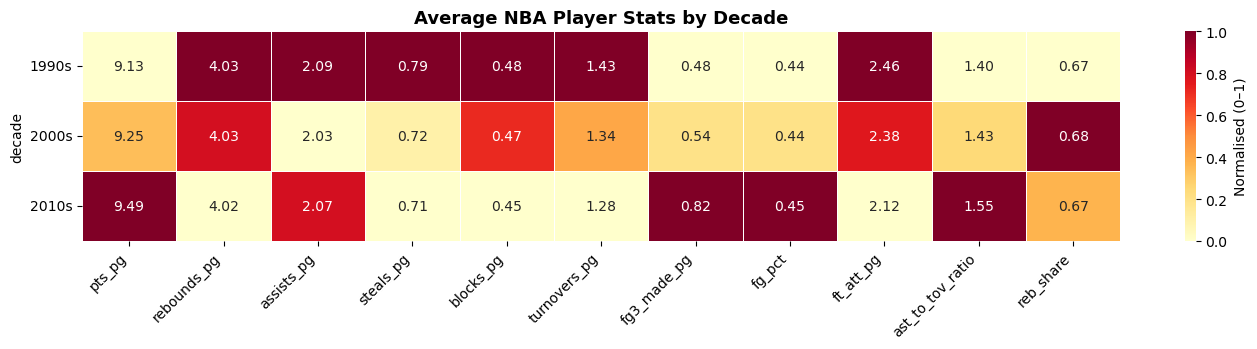


  Clusters chosen per decade:
    1990s: k=5  (1,379 player-seasons)
    2000s: k=5  (3,661 player-seasons)
    2010s: k=4  (3,593 player-seasons)


In [7]:
# STEP 4 — CROSS-DECADE COMPARISON HEATMAP
print("\n" + "═" * 65)
print("STEP 4: Cross-decade comparison...")
print("═" * 65)

if len(decade_results) > 1:
    # Build era means safely as a dict to avoid Series dtype issues
    era_means = []
    for decade_name, df_d in decade_results.items():
        row = {col: df_d[col].mean() for col in CLUSTER_FEATURES}
        row["decade"] = decade_name
        era_means.append(row)

    era_df = pd.DataFrame(era_means).set_index("decade")[CLUSTER_FEATURES]

    # Normalize column-wise — but only if the column has variance
    # Columns with zero variance (max == min) get set to 0.5 to avoid NaN
    era_norm = era_df.copy()
    for col in era_df.columns:
        col_min, col_max = era_df[col].min(), era_df[col].max()
        if col_max > col_min:
            era_norm[col] = (era_df[col] - col_min) / (col_max - col_min)
        else:
            era_norm[col] = 0.5

    fig, ax = plt.subplots(figsize=(14, max(3, len(era_df) * 1.2)))
    sns.heatmap(era_norm, annot=era_df.round(2), fmt=".2f",
                cmap="YlOrRd", linewidths=0.5, ax=ax,
                vmin=0, vmax=1,
                cbar_kws={"label": "Normalised (0–1)"})
    ax.set_title("Average NBA Player Stats by Decade",
                 fontsize=13, fontweight="bold")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("decade_comparison_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n  Clusters chosen per decade:")
    for d, k in decade_chosen_k.items():
        available = len(decade_results.get(d, []))
        print(f"    {d}: k={k}  ({available:,} player-seasons)")

In [18]:
# STEP 5 — CLUSTER SUMMARY TABLES PER DECADE
print("STEP 5: Cluster summary tables...")

top_n_stats  = 3   # number of dominant stats to show per cluster
top_n_players = 10  # number of sample players per cluster

for decade_name in decade_results:
    df_d    = decade_results[decade_name]
    profile = decade_profiles[decade_name]
    chosen_k = decade_chosen_k[decade_name]

    print(f"\n{'═'*65}")
    print(f"  {decade_name}")
    print(f"{'═'*65}")

    # ── 1. Cluster profile table ──────────────────────────────────────────────
    print(f"\n  1. Mean stats per cluster:")
    display_profile = profile[["pts_pg", "rebounds_pg", "assists_pg", "steals_pg",
                                "blocks_pg", "fg3_made_pg", "fg_pct",
                                "ft_att_pg", "ast_to_tov_ratio"]].round(2)
    print(display_profile.to_string())

    # ── 2. Top 3 dominant stats per cluster (by z-score) ─────────────────────
    print(f"\n  2. Top {top_n_stats} dominant stats per cluster (z-score ranked):")
    profile_z = (profile - profile.mean()) / profile.std()
    for c in range(chosen_k):
        top_stats = (profile_z.loc[c]
                               .sort_values(ascending=False)
                               .head(top_n_stats))
        stats_str = ",  ".join([f"{s} ({profile.loc[c, s]:.2f})" 
                                 for s in top_stats.index])
        n = (df_d["cluster"] == c).sum()
        print(f"    Cluster {c} (n={n:,}):  {stats_str}")

    # ── 3. Position breakdown per cluster ────────────────────────────────────
    print(f"\n  3. Position breakdown per cluster (%):")
    pos_table = (df_d.groupby(["cluster", "primary_position"])
                     .size()
                     .unstack(fill_value=0))
    pos_pct = (pos_table.div(pos_table.sum(axis=1), axis=0) * 100).round(1)
    print(pos_pct.to_string())

    # ── 4. Top 5 representative players per cluster ───────────────────────────
    print(f"\n  4. Top {top_n_players} players per cluster (by pts_pg):")
    display_cols = ["player_name", "season", "primary_position",
                    "pts_pg", "rebounds_pg", "assists_pg",
                    "blocks_pg", "fg3_made_pg", "fg_pct"]
    for c in range(chosen_k):
        top = (df_d[df_d["cluster"] == c]
               .sort_values("pts_pg", ascending=False)
               .drop_duplicates("player_name")
               .head(top_n_players)[display_cols]
               .round(2))
        print(f"\n    ── Cluster {c} ──")
        print(top.to_string(index=False))

STEP 5: Cluster summary tables...

═════════════════════════════════════════════════════════════════
  1990s
═════════════════════════════════════════════════════════════════

  1. Mean stats per cluster:
         pts_pg  rebounds_pg  assists_pg  steals_pg  blocks_pg  fg3_made_pg  fg_pct  ft_att_pg  ast_to_tov_ratio
cluster                                                                                                         
0          6.82         2.10        2.21       0.71       0.16         0.72    0.41       1.43              2.02
1         18.61         8.97        2.74       1.05       1.45         0.26    0.48       5.98              1.03
2          9.39         6.24        1.24       0.76       0.81         0.09    0.48       2.81              0.86
3         15.29         3.95        4.90       1.45       0.30         1.20    0.43       3.83              2.10
4          4.09         2.66        0.56       0.37       0.35         0.13    0.44       1.18              0.84

  2

In [15]:
# STEP 6 — SAVE ALL RESULTS
print("STEP 5: Saving results...")

all_decades = []
for decade_name, df_d in decade_results.items():
    df_d["decade"] = decade_name
    all_decades.append(df_d)

if all_decades:
    combined = pd.concat(all_decades, ignore_index=True)
    combined.to_csv("nba_clustered_by_decade.csv", index=False)
    print("  Saved nba_clustered_by_decade.csv")

print("\n  Output files per decade:")
for decade_name in decade_results:
    print(f"    k_selection_{decade_name}.png")
    print(f"    scatter_{decade_name}.png")
    print(f"    radar_{decade_name}.png")
print("    decade_comparison_heatmap.png")
print("    nba_clustered_by_decade.csv")

print("\n DONE.")

STEP 5: Saving results...
  Saved nba_clustered_by_decade.csv

  Output files per decade:
    k_selection_1990s.png
    scatter_1990s.png
    radar_1990s.png
    k_selection_2000s.png
    scatter_2000s.png
    radar_2000s.png
    k_selection_2010s.png
    scatter_2010s.png
    radar_2010s.png
    decade_comparison_heatmap.png
    nba_clustered_by_decade.csv

 DONE.
